# Lecture 2: Regression — Probabilistic Machine Learning
### *Democratizing Machine Learning with Aayush*

---

Welcome to the **Lecture 2** coding companion!  
This notebook translates every concept from the lecture video into runnable, annotated Python code.

**Topics covered:**
1. What is Regression?
2. The L2 / MSE Loss — residuals, quadratic penalty, outlier problem
3. Gaussian output model and its connection to MSE
4. Linear Regression — Least-Squares solution
5. Polynomial Regression — Featurization / Feature Engineering
6. Why Deep Neural Networks? — Automatic Feature Extraction

> **Tip:** Grab a pen and notebook — work through the maths alongside the code!


## 0. Setup — Install & Import Libraries


In [1]:
!pip install numpy matplotlib seaborn scikit-learn torch scipy --quiet


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as sp_norm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import torch, torch.nn as nn, torch.optim as optim

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print('All libraries loaded successfully!')


All libraries loaded successfully!


---
## 1. What is Regression?

In **classification**, the output label $y \in \{C_1, C_2, \ldots, C_K\}$ is one of $K$ discrete classes.  
In **regression**, the output label is a **real-valued number**:

$$y \in \mathbb{R}$$

**Examples from the lecture:**
- Estimating the *height* of a flower from its petal features
- Predicting the *age* of a person from a photo
- Forecasting *house prices* from location & size


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1737/2842697903.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_all, np.sin(X_all), 'r--', linewidth=2, label='True function $\sin(x)$')


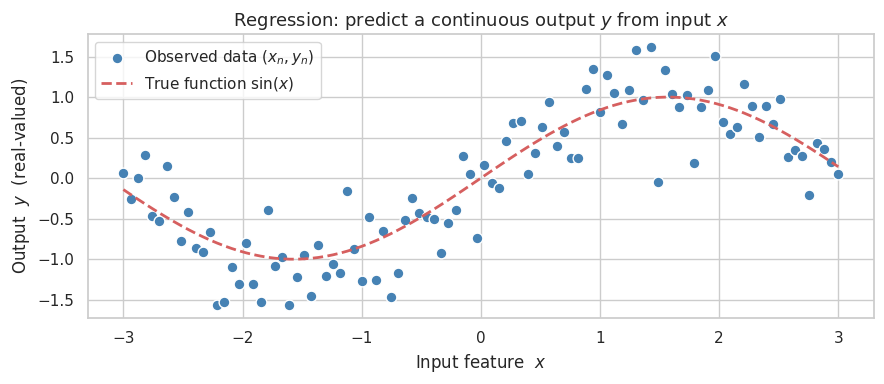

In [3]:
# Visualise a simple 1-D regression problem: predict y from x
N = 100
X_all = np.linspace(-3, 3, N).reshape(-1, 1)
y_all = np.sin(X_all).ravel() + 0.4 * np.random.randn(N)

plt.figure(figsize=(9, 4))
plt.scatter(X_all, y_all, color='steelblue', edgecolor='white', s=60, label='Observed data $(x_n, y_n)$')
plt.plot(X_all, np.sin(X_all), 'r--', linewidth=2, label='True function $\sin(x)$')
plt.title('Regression: predict a continuous output $y$ from input $x$', fontsize=13)
plt.xlabel('Input feature  $x$')
plt.ylabel('Output  $y$  (real-valued)')
plt.legend()
plt.tight_layout()
plt.show()


---
## 2. The Mean Squared Error (MSE) Loss

### 2.1 Residual

For a single example, the **residual** is:

$$\text{residual} = y - \hat{y}$$

We cannot simply sum raw residuals — positive and negative residuals cancel each other out!

### 2.2 Quadratic (L2) Penalty

The squared residual avoids cancellation:

$$\ell_2(y, \hat{y}) = (y - \hat{y})^2 \qquad \text{(quadratic penalty)}$$

### 2.3 Empirical Risk — MSE

Averaging over all $N$ training examples gives the **Mean Squared Error**:

$$\mathcal{L}_{\text{MSE}}(\theta) = \frac{1}{N} \sum_{n=1}^{N} \left( y_n - f(\mathbf{x}_n;\, \theta) \right)^2$$

where $f(\mathbf{x}_n; \theta)$ is our model's prediction parameterised by $\theta$.

### 2.4 L1 vs L2 — Outlier Sensitivity

| Loss | Formula | Behaviour on Outliers |
|------|---------|----------------------|
| **L2 / MSE** | $(y - \hat{y})^2$ | Outliers penalised **quadratically** — can dominate the total loss |
| **L1 / MAE** | $|y - \hat{y}|$ | Outliers penalised **linearly** — more robust |


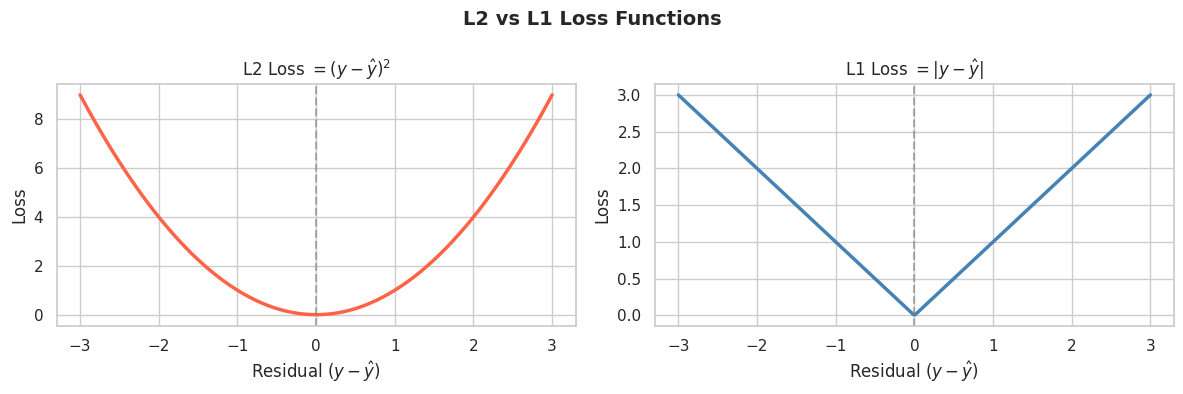

In [4]:
# ── L1 vs L2 loss curves ──
residuals = np.linspace(-3, 3, 300)
L2 = residuals ** 2
L1 = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(residuals, L2, color='tomato', linewidth=2.5)
axes[0].set_title(r'L2 Loss $= (y - \hat{y})^2$', fontsize=12)
axes[0].set_xlabel(r'Residual $(y - \hat{y})$')
axes[0].set_ylabel('Loss')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6)

axes[1].plot(residuals, L1, color='steelblue', linewidth=2.5)
axes[1].set_title(r'L1 Loss $= |y - \hat{y}|$', fontsize=12)
axes[1].set_xlabel(r'Residual $(y - \hat{y})$')
axes[1].set_ylabel('Loss')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6)

plt.suptitle('L2 vs L1 Loss Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [5]:
# ── Outlier impact: L2 vs L1 numerically ──
y_true_vals = np.array([1.0, 2.0, 3.0, 4.0, 10.0])   # last = outlier
y_hat_vals  = np.array([1.1, 1.9, 3.1, 3.8,  4.0])

l2 = (y_true_vals - y_hat_vals) ** 2
l1 = np.abs(y_true_vals - y_hat_vals)

print(f"{'Point':>6} {'True y':>8} {'Pred y':>8} {'L2':>10} {'L1':>10}")
print('-' * 48)
for i, (yt, yp, l2i, l1i) in enumerate(zip(y_true_vals, y_hat_vals, l2, l1)):
    tag = '  <-- OUTLIER' if i == 4 else ''
    print(f"{i+1:>6} {yt:>8.1f} {yp:>8.1f} {l2i:>10.4f} {l1i:>10.4f}{tag}")
print()
print(f"Outlier share of total L2: {l2[-1]/l2.sum()*100:.1f}%")
print(f"Outlier share of total L1: {l1[-1]/l1.sum()*100:.1f}%")
print("=> L2 is dominated by the outlier; L1 is much more robust.")


 Point   True y   Pred y         L2         L1
------------------------------------------------
     1      1.0      1.1     0.0100     0.1000
     2      2.0      1.9     0.0100     0.1000
     3      3.0      3.1     0.0100     0.1000
     4      4.0      3.8     0.0400     0.2000
     5     10.0      4.0    36.0000     6.0000  <-- OUTLIER

Outlier share of total L2: 99.8%
Outlier share of total L1: 92.3%
=> L2 is dominated by the outlier; L1 is much more robust.


---
## 3. Gaussian Output Distribution → MSE Connection

### 3.1 Why Model Uncertainty?

ML models are inherently stochastic — two inputs that look alike may yield different outputs due to noise.  
We capture this with a **conditional probability distribution** over $y$:

$$p(y \mid \mathbf{x};\ \theta)$$

### 3.2 Why the Gaussian?

1. Only two parameters: mean $\mu$ and variance $\sigma^2$ — easy to interpret
2. **Maximum entropy** distribution given a fixed variance (least assumptions)
3. **Central Limit Theorem** — sums of many independent random effects converge to Gaussian

### 3.3 The Gaussian Output Model

$$p(y \mid \mathbf{x};\ \theta) = \mathcal{N}\!\left(y;\ f(\mathbf{x};\ \theta),\ \sigma^2\right) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y - f(\mathbf{x};\ \theta))^2}{2\sigma^2}\right)$$

The model prediction $f(\mathbf{x};\ \theta)$ is the **mean** $\mu$ of the Gaussian.

- **Homoscedastic regression:** $\sigma^2$ is fixed (same noise everywhere)
- **Heteroscedastic regression:** $\sigma^2 = \sigma^2(\mathbf{x})$ varies with input

### 3.4 Negative Log-Likelihood (NLL) → MSE

$$\mathcal{L}_{\text{NLL}}(\theta) = -\frac{1}{N}\sum_{n=1}^{N} \log p(y_n \mid \mathbf{x}_n;\ \theta)$$

Substituting the Gaussian form:

$$= -\frac{1}{N}\sum_{n=1}^{N} \left[ -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(y_n - f(\mathbf{x}_n;\ \theta))^2}{2\sigma^2} \right]$$

$$= \underbrace{\frac{1}{2\sigma^2}}_{\text{const.}} \cdot \frac{1}{N}\sum_{n=1}^{N}(y_n - f(\mathbf{x}_n;\ \theta))^2 + \underbrace{\frac{1}{2}\log(2\pi\sigma^2)}_{\text{const.}}$$

$$\boxed{\mathcal{L}_{\text{NLL}}(\theta) \propto \mathcal{L}_{\text{MSE}}(\theta)}$$

**Key insight:** Minimising MSE is *exactly* Maximum Likelihood Estimation under a Gaussian noise model!


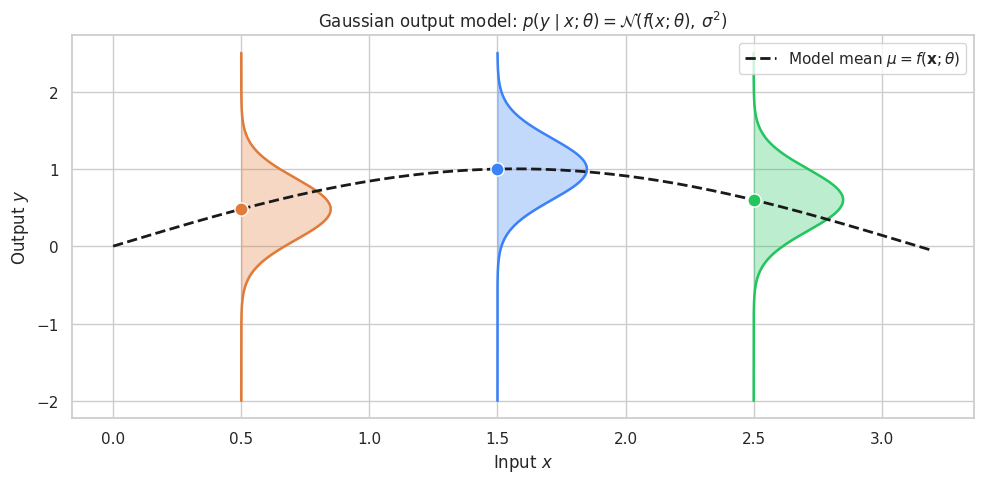

sigma = 0.4: controls the width/uncertainty of each Gaussian bell.


In [6]:
# ── Visualise Gaussian output model p(y|x; theta) ──
sigma = 0.4
x_pts = np.array([0.5, 1.5, 2.5])
mu_pts = np.sin(x_pts)

fig, ax = plt.subplots(figsize=(10, 5))
y_range = np.linspace(-2, 2.5, 300)
colors = ['#e07b39', '#3b82f6', '#22c55e']

for xi, mui, col in zip(x_pts, mu_pts, colors):
    pdf = sp_norm.pdf(y_range, loc=mui, scale=sigma)
    pdf_scaled = pdf * 0.35
    ax.fill_betweenx(y_range, xi, xi + pdf_scaled, alpha=0.3, color=col)
    ax.plot(xi + pdf_scaled, y_range, color=col, linewidth=1.8)
    ax.scatter([xi], [mui], color=col, zorder=5, s=90, edgecolor='white')

x_curve = np.linspace(0, 3.2, 200)
ax.plot(x_curve, np.sin(x_curve), 'k--', linewidth=2,
        label=r'Model mean $\mu = f(\mathbf{x};\theta)$')
ax.set_title(r'Gaussian output model: $p(y\mid x;\theta) = \mathcal{N}(f(x;\theta),\,\sigma^2)$', fontsize=12)
ax.set_xlabel('Input $x$')
ax.set_ylabel('Output $y$')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print(f'sigma = {sigma}: controls the width/uncertainty of each Gaussian bell.')


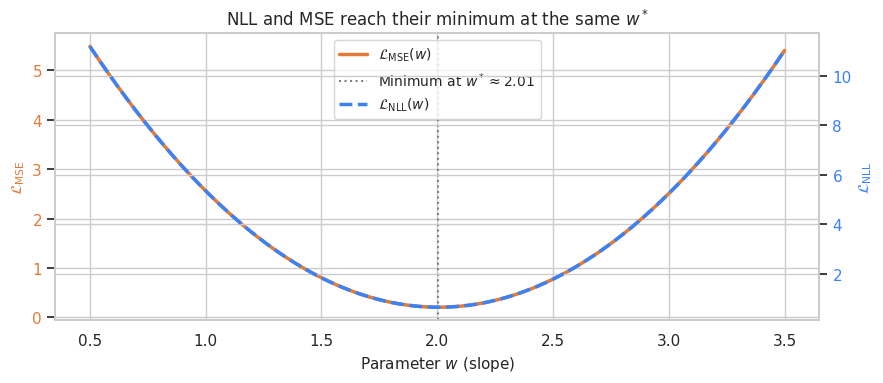

MSE minimum at w = 2.005
NLL minimum at w = 2.005
=> NLL ∝ MSE confirmed numerically!


In [7]:
# ── Numerically verify: NLL and MSE share the same minimum ──
np.random.seed(7)
N_d = 60
X_d = np.random.uniform(-3, 3, N_d)
y_d = 2.0 * X_d + 1.0 + np.random.randn(N_d) * 0.5

w_grid = np.linspace(0.5, 3.5, 300)   # sweep over slope w
b_fixed = 1.0                          # keep intercept fixed
sigma_fixed = 0.5

mse_vals, nll_vals = [], []
for w in w_grid:
    yhat = w * X_d + b_fixed
    mse_vals.append(np.mean((y_d - yhat)**2))
    nll_vals.append(-np.mean(sp_norm.logpdf(y_d, loc=yhat, scale=sigma_fixed)))

fig, ax1 = plt.subplots(figsize=(9, 4))
c1, c2 = '#e07b39', '#3b82f6'
ax1.plot(w_grid, mse_vals, color=c1, linewidth=2.5, label=r'$\mathcal{L}_{\mathrm{MSE}}(w)$')
ax1.set_xlabel('Parameter $w$ (slope)', fontsize=11)
ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{MSE}}$', color=c1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=c1)

ax2 = ax1.twinx()
ax2.plot(w_grid, nll_vals, color=c2, linewidth=2.5, linestyle='--',
         label=r'$\mathcal{L}_{\mathrm{NLL}}(w)$')
ax2.set_ylabel(r'$\mathcal{L}_{\mathrm{NLL}}$', color=c2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=c2)

w_star = w_grid[np.argmin(mse_vals)]
ax1.axvline(w_star, color='gray', linestyle=':', linewidth=1.5,
            label=f'Minimum at $w^* \\approx {w_star:.2f}$')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=10)
ax1.set_title(r'NLL and MSE reach their minimum at the same $w^*$', fontsize=12)
plt.tight_layout()
plt.show()

print(f'MSE minimum at w = {w_grid[np.argmin(mse_vals)]:.3f}')
print(f'NLL minimum at w = {w_grid[np.argmin(nll_vals)]:.3f}')
print(r'=> NLL ∝ MSE confirmed numerically!')


---
## 4. Linear Regression — Least Squares Solution

### The Model

$$f(\mathbf{x};\ w, b) = w\, x + b$$

(for scalar $x$; generalises to $f(\mathbf{x}; \mathbf{w}) = \mathbf{w}^\top \mathbf{x}$ with bias absorbed)

### Objective

Find $\hat{\theta} = \arg\min_{\theta}\, \mathcal{L}_{\text{MSE}}(\theta)$ — the **Least Squares** solution.

### Why a Unique Global Minimum?

When $f$ is **linear in its parameters** $\mathbf{w}$, the MSE loss surface is a **convex bowl** in parameter space:

$$\mathcal{L}_{\text{MSE}}(\mathbf{w}) \text{ is a convex quadratic in } \mathbf{w} \Rightarrow \text{unique global minimum}$$

**Gradient descent** — moving opposite to $\nabla_\theta \mathcal{L}$:

$$\theta \leftarrow \theta - \eta\, \nabla_\theta \mathcal{L}_{\text{MSE}}(\theta)$$

always converges to the global minimum for a linear model.


Learned w (slope)     = 1.5379  (true: 1.5)
Learned b (intercept) = 0.3662  (true: 0.5)
Train MSE = 0.5194
Test  MSE = 0.8327


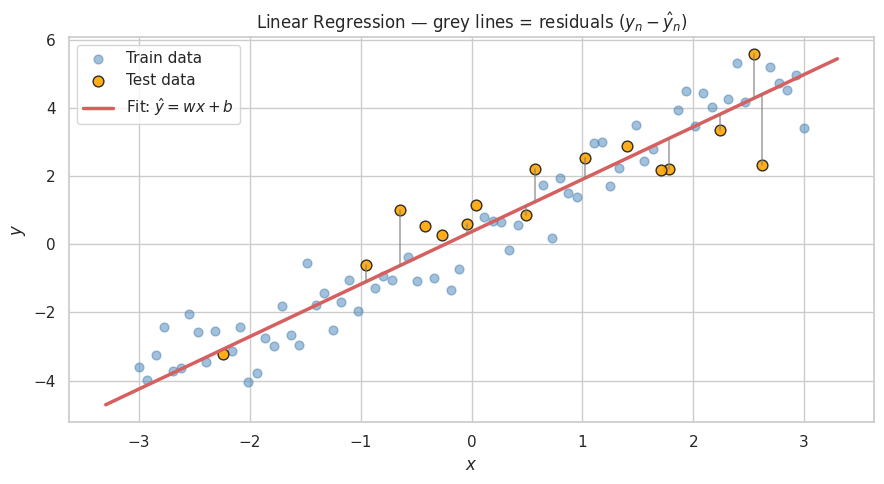

In [8]:
# ── Fit linear regression and plot residuals ──
np.random.seed(42)
N = 80
X_lr = np.linspace(-3, 3, N).reshape(-1, 1)
y_lr = 1.5 * X_lr.ravel() + 0.5 + 0.8 * np.random.randn(N)

X_tr, X_te, y_tr, y_te = train_test_split(X_lr, y_lr, test_size=0.2, random_state=1)
lin = LinearRegression().fit(X_tr, y_tr)

print(f'Learned w (slope)     = {lin.coef_[0]:.4f}  (true: 1.5)')
print(f'Learned b (intercept) = {lin.intercept_:.4f}  (true: 0.5)')
print(f'Train MSE = {mean_squared_error(y_tr, lin.predict(X_tr)):.4f}')
print(f'Test  MSE = {mean_squared_error(y_te, lin.predict(X_te)):.4f}')

X_plot = np.linspace(-3.3, 3.3, 200).reshape(-1, 1)
plt.figure(figsize=(9, 5))
plt.scatter(X_tr, y_tr, color='steelblue', alpha=0.5, s=40, label='Train data')
plt.scatter(X_te, y_te, color='orange', alpha=0.9, s=60, edgecolor='k', label='Test data')
plt.plot(X_plot, lin.predict(X_plot), 'r-', linewidth=2.5,
         label=r'Fit: $\hat{y} = wx + b$')

# Draw residual lines
for xi, yi, ypi in zip(X_te[:10].ravel(), y_te[:10], lin.predict(X_te[:10])):
    plt.plot([xi, xi], [yi, ypi], color='gray', linewidth=1.2, alpha=0.7)

plt.title(r'Linear Regression — grey lines = residuals $(y_n - \hat{y}_n)$', fontsize=12)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.tight_layout()
plt.show()


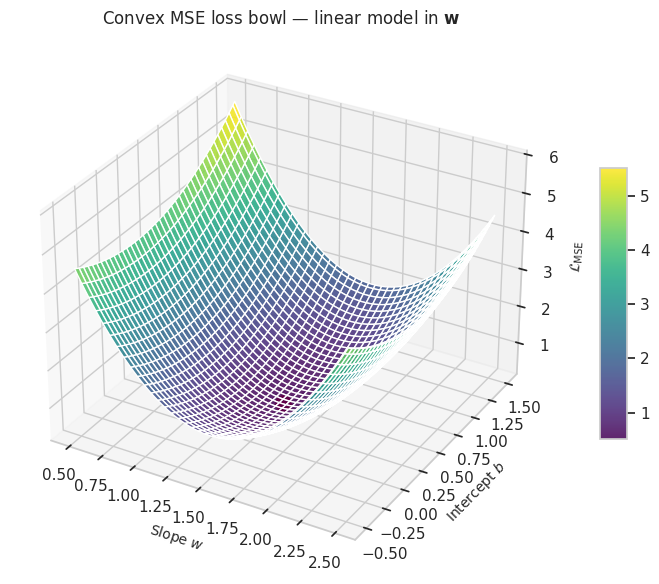

The bowl has exactly ONE lowest point => unique global minimum.


In [9]:
# ── Visualise the convex MSE loss surface ──
slopes = np.linspace(0.5, 2.5, 80)
intercepts = np.linspace(-0.5, 1.5, 80)
W, B = np.meshgrid(slopes, intercepts)

MSE_surf = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        yh = W[i,j] * X_tr.ravel() + B[i,j]
        MSE_surf[i,j] = np.mean((y_tr - yh)**2)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(W, B, MSE_surf, cmap='viridis', alpha=0.85)
ax.scatter([lin.coef_[0]], [lin.intercept_],
           [mean_squared_error(y_tr, lin.predict(X_tr))],
           color='red', s=120, zorder=10, label='Global minimum $\\hat{\\theta}$')
ax.set_xlabel('Slope $w$', fontsize=10)
ax.set_ylabel('Intercept $b$', fontsize=10)
ax.set_zlabel(r'$\mathcal{L}_{\mathrm{MSE}}$', fontsize=10)
ax.set_title(r'Convex MSE loss bowl — linear model in $\mathbf{w}$', fontsize=12)
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()
print('The bowl has exactly ONE lowest point => unique global minimum.')


---
## 5. Polynomial Regression — Featurization

### The Problem

If the data follows a curved pattern, the linear model $f = \mathbf{w}^\top \mathbf{x}$ gives a poor fit.

### Solution: Featurization (Feature Engineering)

Transform the raw input into a richer feature vector $\boldsymbol{\phi}(\mathbf{x})$:

$$\boldsymbol{\phi}(x) = \begin{bmatrix} 1 \\ x \\ x^2 \\ \vdots \\ x^d \end{bmatrix}$$

Then the model becomes:

$$f(x;\ \mathbf{w}) = \mathbf{w}^\top \boldsymbol{\phi}(x) = w_0 + w_1 x + w_2 x^2 + \cdots + w_d x^d$$

### Key Properties

| Property | Value |
|---|---|
| Linear in $\mathbf{x}$? | **No** — $x^2, x^3, \ldots$ are non-linear |
| Linear in $\mathbf{w}$? | **Yes** — $\mathbf{w}^\top \boldsymbol{\phi}(x)$ is linear in $\mathbf{w}$ |
| MSE loss surface | Still a **convex bowl** in $\mathbf{w}$ — unique global minimum |

> **Warning:** Very high degree $d$ can cause **overfitting** (covered in Lecture 3)


In [10]:
# ── Show featurization explicitly ──
x_sample = np.array([[2.0]])
print('Featurization example for x = 2.0')
print(f"{'Degree d':>10} | phi(x) vector")
print('-' * 55)
for deg in [1, 2, 3, 4]:
    phi = PolynomialFeatures(degree=deg, include_bias=True).fit_transform(x_sample).ravel()
    terms = ',  '.join([f'x^{i}={v:.1f}' for i, v in enumerate(phi)])
    print(f"{deg:>10} | [{terms}]")

print()
print('f(x; w) = w^T phi(x) is LINEAR in w even though phi(x) is nonlinear in x.')
print('=> The MSE landscape remains a convex bowl!')


Featurization example for x = 2.0
  Degree d | phi(x) vector
-------------------------------------------------------
         1 | [x^0=1.0,  x^1=2.0]
         2 | [x^0=1.0,  x^1=2.0,  x^2=4.0]
         3 | [x^0=1.0,  x^1=2.0,  x^2=4.0,  x^3=8.0]
         4 | [x^0=1.0,  x^1=2.0,  x^2=4.0,  x^3=8.0,  x^4=16.0]

f(x; w) = w^T phi(x) is LINEAR in w even though phi(x) is nonlinear in x.
=> The MSE landscape remains a convex bowl!


  Degree |    Train MSE |     Test MSE
--------------------------------------
       1 |       0.2315 |       0.2136
       3 |       0.0905 |       0.0778
       7 |       0.0874 |       0.0741
      15 |       0.0736 |       0.1262


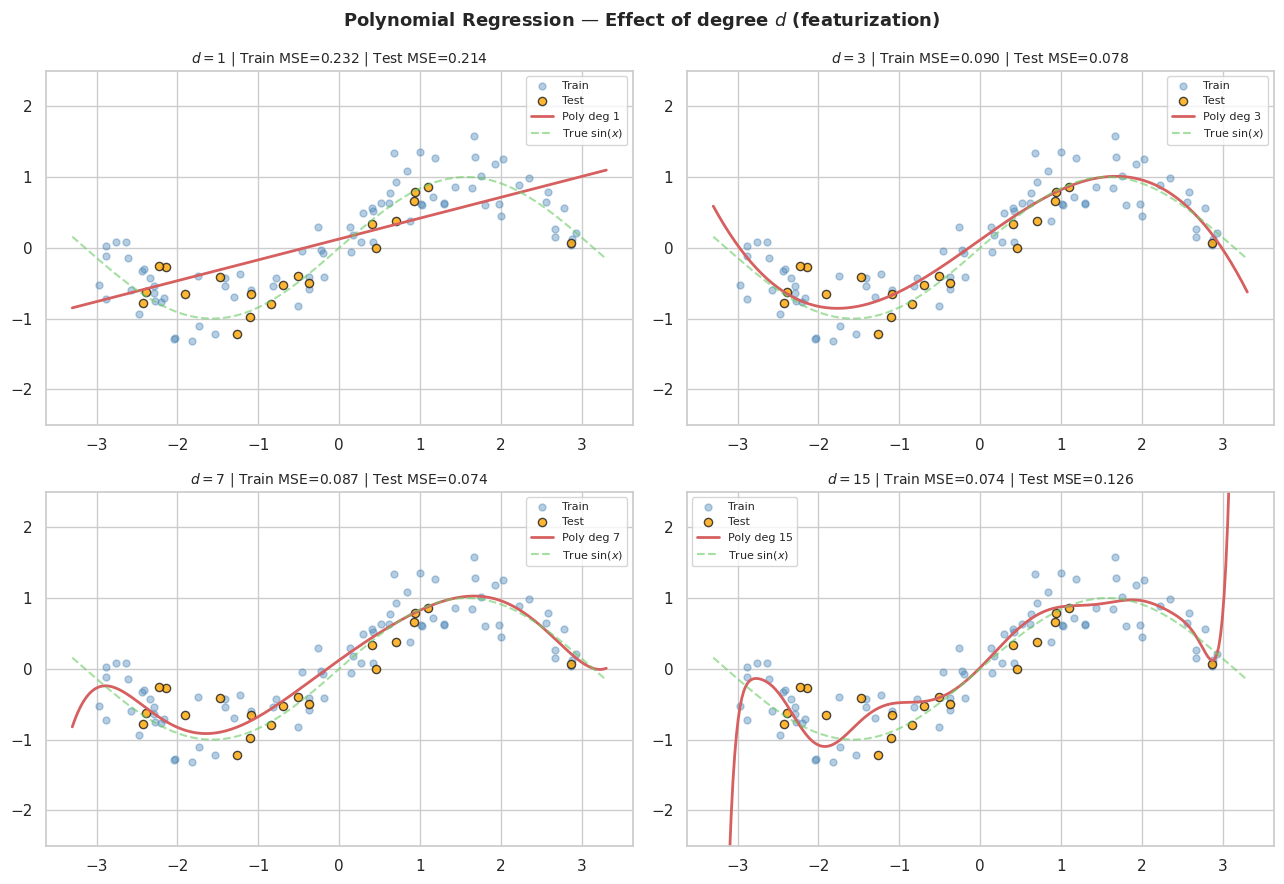

In [11]:
# ── Compare polynomial fits of different degrees ──
np.random.seed(0)
N = 100
X_nl = np.sort(np.random.uniform(-3, 3, N))
y_nl = np.sin(X_nl) + 0.3 * np.random.randn(N)
X_nl2 = X_nl.reshape(-1, 1)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_nl2, y_nl, test_size=0.2, random_state=5)
X_plot2 = np.linspace(-3.3, 3.3, 300).reshape(-1, 1)
degrees = [1, 3, 7, 15]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

print(f"{'Degree':>8} | {'Train MSE':>12} | {'Test MSE':>12}")
print('-' * 38)

for ax, deg in zip(axes, degrees):
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=True), LinearRegression())
    pipe.fit(X_tr2, y_tr2)
    tr_mse = mean_squared_error(y_tr2, pipe.predict(X_tr2))
    te_mse = mean_squared_error(y_te2, pipe.predict(X_te2))
    print(f"{deg:>8} | {tr_mse:>12.4f} | {te_mse:>12.4f}")

    ax.scatter(X_tr2, y_tr2, color='steelblue', alpha=0.4, s=25, label='Train')
    ax.scatter(X_te2, y_te2, color='orange', alpha=0.8, s=35, edgecolor='k', label='Test')
    ax.plot(X_plot2, pipe.predict(X_plot2), 'r-', linewidth=2, label=f'Poly deg {deg}')
    ax.plot(X_plot2, np.sin(X_plot2), 'g--', linewidth=1.5, alpha=0.6, label=r'True $\sin(x)$')
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f'$d={deg}$ | Train MSE={tr_mse:.3f} | Test MSE={te_mse:.3f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(r'Polynomial Regression — Effect of degree $d$ (featurization)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Why Deep Neural Networks? — Automatic Feature Extraction

### The Problem with Manual Featurization

For high-dimensional inputs (images, text, sensor data), choosing $\boldsymbol{\phi}(\mathbf{x})$ manually is infeasible.  
This is the **curse of dimensionality**: the number of polynomial terms grows exponentially with input dimension.

### The Big Idea: Make $\boldsymbol{\phi}$ Learnable

Instead of engineering $\boldsymbol{\phi}(\mathbf{x})$ by hand, introduce parameters $\mathbf{v}$ for it:

$$f(\mathbf{x};\ \theta) = \mathbf{w}^\top \boldsymbol{\phi}_\mathbf{v}(\mathbf{x}), \qquad \theta = \{\mathbf{w},\, \mathbf{v}\}$$

Both $\mathbf{w}$ and $\mathbf{v}$ are learned from data!

### How? — Composition of Layers

Decompose $\boldsymbol{\phi}_\mathbf{v}(\mathbf{x})$ as a **nested composition** of $L-1$ simpler functions (layers):

$$\boldsymbol{\phi}_\mathbf{v}(\mathbf{x}) = f_{L-1}\!\left(\cdots f_2\!\left(f_1(\mathbf{x};\ \theta_1);\ \theta_2\right) \cdots;\, \theta_{L-1}\right)$$

Each layer $f_l$ has its own learnable parameters $\theta_l$.  
The full model is therefore:

$$f(\mathbf{x};\ \theta) = \underbrace{\mathbf{w}^\top}_{\text{linear head}} \underbrace{\boldsymbol{\phi}_\mathbf{v}(\mathbf{x})}_{\text{learned feature extractor: layers } 1 \text{ to } L-1}$$

This **composition of many layers** is a **Deep Neural Network**!

### Trade-off

Because $\boldsymbol{\phi}_\mathbf{v}(\mathbf{x})$ is **non-linear**, the MSE loss is **no longer convex** — gradient descent may find local minima.  
We handle this with careful initialisation, large datasets, and optimisation tricks (future lectures).


In [12]:
# ── Build a 2-hidden-layer neural network that learns phi(x) automatically ──

X_tr_t = torch.from_numpy(X_tr2).float()
y_tr_t = torch.from_numpy(y_tr2).float().unsqueeze(1)
X_te_t = torch.from_numpy(X_te2).float()
y_te_t = torch.from_numpy(y_te2).float().unsqueeze(1)

class DeepRegressionNet(nn.Module):
    """
    Implements  f(x; theta) = w^T * phi_v(x)

    feature_extractor  = phi_v(x)   [layers 1 ... L-1]   learnable
    linear_head        = w^T         [layer L]            linear predictor
    """
    def __init__(self, hidden=64):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.linear_head = nn.Linear(hidden, 1)

    def forward(self, x):
        phi = self.feature_extractor(x)   # learned phi(x)
        return self.linear_head(phi)      # w^T phi(x)

model = DeepRegressionNet(hidden=64)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')


DeepRegressionNet(
  (feature_extractor): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
  )
  (linear_head): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 4353


In [13]:
# ── Train the network (minimise MSE loss via gradient descent) ──
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses, test_losses = [], []
EPOCHS = 2000

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    loss_tr = criterion(model(X_tr_t), y_tr_t)
    loss_tr.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        loss_te = criterion(model(X_te_t), y_te_t)

    train_losses.append(loss_tr.item())
    test_losses.append(loss_te.item())

    if (epoch + 1) % 500 == 0:
        print(f'Epoch {epoch+1:>5}/{EPOCHS}  |  Train MSE: {loss_tr.item():.4f}  |  Test MSE: {loss_te.item():.4f}')

print(f'\nFinal Train MSE : {train_losses[-1]:.4f}')
print(f'Final Test  MSE : {test_losses[-1]:.4f}')


Epoch   500/2000  |  Train MSE: 0.0894  |  Test MSE: 0.0716
Epoch  1000/2000  |  Train MSE: 0.0786  |  Test MSE: 0.1096
Epoch  1500/2000  |  Train MSE: 0.0725  |  Test MSE: 0.1239
Epoch  2000/2000  |  Train MSE: 0.0712  |  Test MSE: 0.1260

Final Train MSE : 0.0712
Final Test  MSE : 0.1260


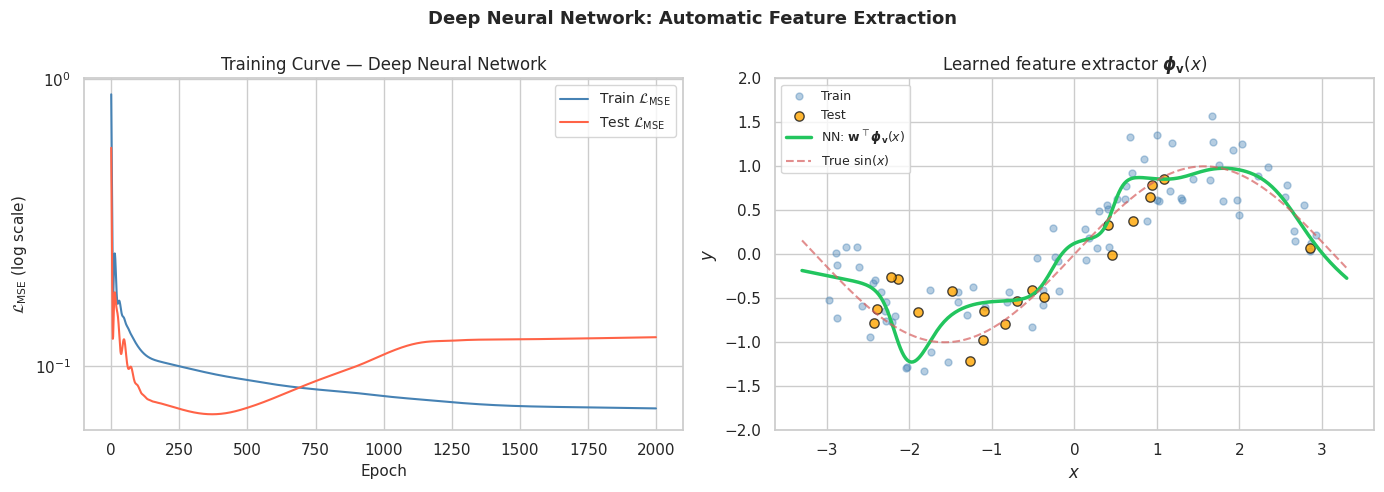

In [14]:
# ── Plot training curve + final learned fit ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color='steelblue', linewidth=1.5, label=r'Train $\mathcal{L}_{\mathrm{MSE}}$')
ax1.plot(test_losses, color='tomato', linewidth=1.5, label=r'Test $\mathcal{L}_{\mathrm{MSE}}$')
ax1.set_yscale('log')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{MSE}}$ (log scale)', fontsize=11)
ax1.set_title('Training Curve — Deep Neural Network', fontsize=12)
ax1.legend(fontsize=10)

X_plot_t = torch.from_numpy(X_plot2).float()
model.eval()
with torch.no_grad():
    y_nn = model(X_plot_t).numpy().ravel()

ax2.scatter(X_tr2, y_tr2, color='steelblue', alpha=0.4, s=25, label='Train')
ax2.scatter(X_te2, y_te2, color='orange', alpha=0.8, s=45, edgecolor='k', label='Test')
ax2.plot(X_plot2, y_nn, '#22c55e', linewidth=2.5,
         label=r'NN: $\mathbf{w}^\top \boldsymbol{\phi}_\mathbf{v}(x)$')
ax2.plot(X_plot2, np.sin(X_plot2), 'r--', linewidth=1.5, alpha=0.7, label=r'True $\sin(x)$')
ax2.set_ylim(-2, 2)
ax2.set_title(r'Learned feature extractor $\boldsymbol{\phi}_\mathbf{v}(x)$', fontsize=12)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.legend(fontsize=9)

plt.suptitle('Deep Neural Network: Automatic Feature Extraction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


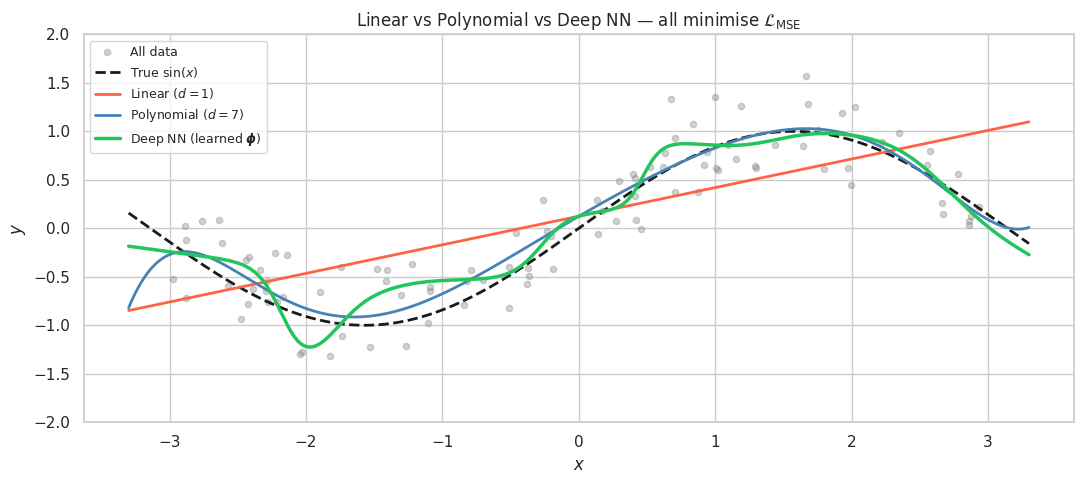

Test MSE Comparison:
  Linear     (d=1) : 0.2136
  Polynomial (d=7) : 0.0741
  Deep NN          : 0.1260


In [15]:
# ── Final comparison: Linear vs Polynomial vs Deep NN ──
lin2  = LinearRegression().fit(X_tr2, y_tr2)
poly7 = make_pipeline(PolynomialFeatures(7), LinearRegression()).fit(X_tr2, y_tr2)

model.eval()
with torch.no_grad():
    y_nn_cmp = model(X_plot_t).numpy().ravel()

plt.figure(figsize=(11, 5))
plt.scatter(X_nl, y_nl, color='gray', alpha=0.35, s=20, label='All data')
plt.plot(X_plot2, np.sin(X_plot2), 'k--', linewidth=2, label=r'True $\sin(x)$')
plt.plot(X_plot2, lin2.predict(X_plot2),  color='tomato',    linewidth=2, label='Linear ($d=1$)')
plt.plot(X_plot2, poly7.predict(X_plot2), color='steelblue', linewidth=2, label='Polynomial ($d=7$)')
plt.plot(X_plot2, y_nn_cmp,               color='#22c55e',   linewidth=2.5,
         label=r'Deep NN (learned $\boldsymbol{\phi}$)')
plt.ylim(-2, 2)
plt.title(r'Linear vs Polynomial vs Deep NN — all minimise $\mathcal{L}_{\mathrm{MSE}}$', fontsize=12)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Test MSE Comparison:')
print(f'  Linear     (d=1) : {mean_squared_error(y_te2, lin2.predict(X_te2)):.4f}')
print(f'  Polynomial (d=7) : {mean_squared_error(y_te2, poly7.predict(X_te2)):.4f}')
with torch.no_grad():
    nn_te = model(X_te_t).numpy().ravel()
print(f'  Deep NN          : {mean_squared_error(y_te2, nn_te):.4f}')


---
## Summary

| Concept | Key Formula / Idea |
|---|---|
| **Regression** | $y \in \mathbb{R}$ — predict a real-valued output |
| **Residual** | $y_n - \hat{y}_n$ |
| **L2 / MSE Loss** | $\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_n (y_n - f(\mathbf{x}_n;\theta))^2$ |
| **Gaussian output** | $p(y\mid\mathbf{x};\theta) = \mathcal{N}(f(\mathbf{x};\theta),\,\sigma^2)$ |
| **NLL ∝ MSE** | Minimising MSE = MLE under Gaussian noise |
| **Linear regression** | Linear in $\mathbf{w}$ → convex bowl → unique global minimum |
| **Featurization** | $f = \mathbf{w}^\top\boldsymbol{\phi}(\mathbf{x})$; still linear in $\mathbf{w}$ |
| **Deep NN** | Make $\boldsymbol{\phi}_\mathbf{v}(\mathbf{x})$ learnable via composition of layers |

---
**Next Lecture:** Overfitting & Generalisation

> Keep a notebook and pen handy — work through the derivations as you re-watch the lecture!
